# PHYS 332 - Numerical Techniques for the Sciences II
## Homework 01: Ordinary Differential Equations
### Problem 3 -  An Adaptive Solution to the Analytic Problem
---
Name: *Ethan Duarte*

Cells for *Problem 3* are below.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

## Your RK45 Step and Stepping Function go Here

In [2]:
def rk45step(y,f,x,h):

    """
    Advances solution by a single RK45 step.  Note that this
    
    PARAMETERS:
    input:
        y -- initial value, scalar;
        f -- function (RHS of ODE);
        x -- starting x.
        h -- stepsize

    RETURNS:
        ynew  :  new RK45 step
        error :  The error incurred this timestep

        See the assignment sheet for additional details about these
        function parameters.
    """
   

    ## Your code goes here
    c = np.array([np.nan, 1/5, 3/10, 4/5, 8/9, 1, 1])

    a = np.array([[np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
                  [1/5, np.nan, np.nan, np.nan, np.nan, np.nan],
                  [3/40, 9/40, np.nan, np.nan, np.nan, np.nan],
                  [44/45, -56/15, 32/9, np.nan, np.nan, np.nan],
                  [19372/6561, -25360/2187, 64448/6561, -212/729, np.nan, np.nan],
                  [9017/3168, -355/33, 46732/5247, 49/176, -5103/18656, np.nan],
                  [35/384, 0, 500/1113, 125/192, -2187/6784, 11/84]])

    b = np.array([35/384, 0, 500/1113, 125/192, -2187/6784, 11/84, 0])

    bstar = np.array([5179/57600, 0, 7571/16695, 393/640,
                      -92097/339200, 187/2100, 1/40])


    k1 = h * f(x,y)

    k2 = h * f(x + c[1] * h,
               y + a[1][0] * k1)

    k3 = h * f(x + c[2] * h,
               y + a[2][0] * k1 + a[2][1] * k2)

    k4 = h * f(x + c[3] * h,
               y + a[3][0] * k1 + a[3][1] * k2 + a[3][2] * k3)

    k5 = h * f(x + c[4] * h,
               y + a[4][0] * k1 + a[4][1] * k2
                 + a[4][2] * k3 + a[4][3] * k4)

    k6 = h * f(x + c[5] * h,
               y + a[5][0] * k1 + a[5][1] * k2
                 + a[5][2] * k3 + a[5][3] * k4
                 + a[5][4] * k5)


    ynew = y + b[0] * k1 + b[1] * k2 + b[2] * k3 \
             + b[3] * k4 + b[4] * k5 + b[5] * k6


    k7 = h * f(x + h, ynew)


    ynewstar = y + bstar[0] * k1 + bstar[1] * k2 \
                 + bstar[2] * k3 + bstar[3] * k4 \
                 + bstar[4] * k5 + bstar[5] * k6 \
                 + bstar[6] * k7


    error = ynew - ynewstar

    return(ynew, error)

def ode_adaptivestep(f,x0,y0,x1,errtol,h0):

    """
    Solves an ordinary differential equation
    using adaptive step size.

    PARAMETERS:
    input:
        f      : inline function (RHS of ODE)
        x0     : starting x.
        y0     : starting y (scalar).
        x1     : end x.
        h0     : inital step size (only used once)
        errtol : Error tolerance 

    output:
        x      : positions of n+1 steps
        y      : (nstep+1,1) vector of resulting y's
    
     comment  : dx is determined automatically by the RK45
                so you want to just keep running until x > x1             
    """

    x = x0
    y = y0
    h = h0

    abs_tol = 1e-12
    s = 0.9

    ## You'll want to save your x and y values here every timestep
    x_outputs = [x]
    y_outputs = [y]

    function_evals = 0

    while x < x1:

        h = min(h, x1 - x)

        ynew, delta = rk45step(y, f, x, h)

        function_evals += 7

        scale = abs_tol + max(np.abs(y), np.abs(ynew)) * errtol
        err = np.abs(delta) / scale

        err = max(err, 1e-16)

        hnew = s * h * (1 / err) ** (1/5)

        if err <= 1:

            x = x + h
            y = ynew

            x_outputs.append(x)
            y_outputs.append(y)

        h = hnew

    return np.array(x_outputs), np.array(y_outputs), function_evals

In [3]:
def RHS(x,y):

## Your code goes here
    dydx = np.exp(y - 2 * x) + 2
    return dydx

        

1e-08 1.7175399923791582e-09 63
1e-09 1.0735246508880421e-10 98
1e-10 2.8357330467416753e-10 147
1e-11 1.0285139410785015e-12 196


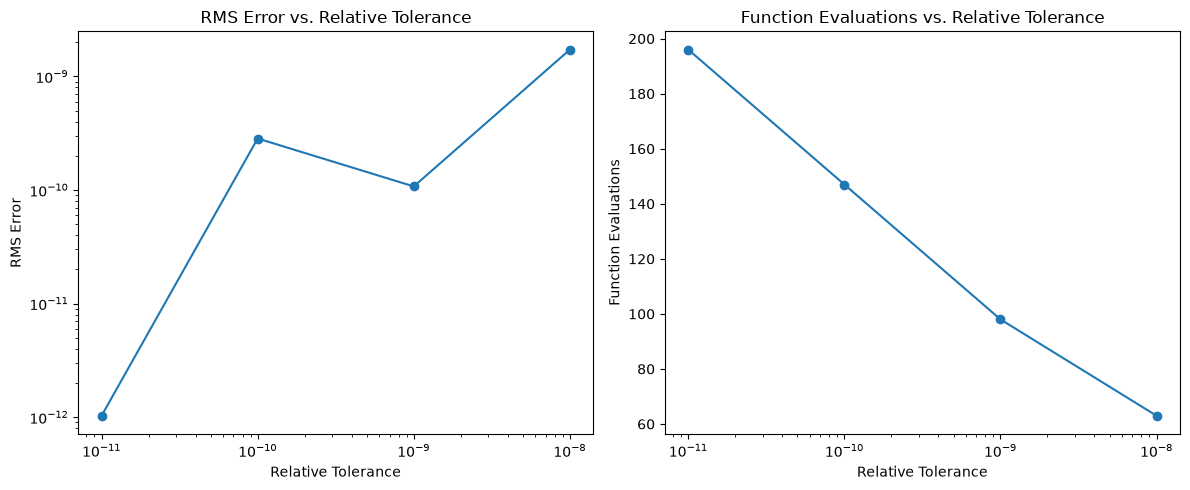

In [4]:
def anSol(x):
    return 2 * x - np.log(np.abs(2 - x))


tolerances = [1e-8, 1e-9, 1e-10, 1e-11]

rms_errors = []
function_evals = []


for tol in tolerances:

    x_num, y_num, n_eval = ode_adaptivestep(
        RHS, 0, -np.log(2), 1, tol, 0.01
    )

    error = (y_num - anSol(x_num)) / anSol(x_num)

    nstep = len(x_num) - 1

    rms_error = np.sqrt(
        np.sum(error ** 2 / nstep)
    )

    rms_errors.append(rms_error)
    function_evals.append(n_eval)

    print(tol, rms_error, n_eval)


#Plotting Stuff so it's pretty <3

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].loglog(
    tolerances,
    rms_errors,
    marker="o"
)

ax[1].semilogx(
    tolerances,
    function_evals,
    marker="o"
)

ax[0].set_xlabel("Relative Tolerance")
ax[0].set_ylabel("RMS Error")
ax[0].set_title("RMS Error vs. Relative Tolerance")

ax[1].set_xlabel("Relative Tolerance")
ax[1].set_ylabel("Function Evaluations")
ax[1].set_title("Function Evaluations vs. Relative Tolerance")

plt.tight_layout()
plt.show()